# QGSS 2026 실습 2 — Qiskit의 noise, backend 및 benchmarking

실습 2에 오신 것을 환영합니다.

이번 실습에서는 앞선 실습에서 다룬 회로 모델을 **실제 양자 하드웨어**와 연결합니다.
양자 회로는 여전히 계산을 논리적으로 기술하지만, 실제 실행 방식은 native gate, connectivity, gate fidelity, readout performance, coherence time과 같은 (실시간) backend의 성능에 따라 달라집니다.

이 실습의 목표는 이러한 하드웨어 세부 정보를 실제 엔지니어링 정보로 활용하는 것입니다.
이를 통해 layout을 선택하고, backend-aware simulator를 구축하며, 서로 다른 architecture가 transpiled circuit과 측정 결과에 어떤 영향을 주는지 비교할 수 있습니다.

이 노트북을 마치면 다음 네 가지 실용적인 질문에 답할 수 있어야 합니다.

1. **hardware noise와 회로 크기는 측정 결과에 어떤 영향을 주는가?**
2. **backend에는 어떤 정보가 포함되어 있는가?**
3. **Qiskit에서 backend-aware noise를 어떻게 시뮬레이션하는가?**
4. **서로 다른 backend를 간단하고 정량적인 방법으로 어떻게 비교하는가?**


## 목차

- [설치](#installation)
- [라이브러리 불러오기](#imports)
- [도우미 함수](#helper-functions)
- [노트북 공통 설정](#shared-setup-for-the-notebook)
- [1장 — 양자컴퓨터의 noise와 backend-aware 시뮬레이션](#chapter-1--noise-in-quantum-computers-and-backend-aware-simulation)
  - [1.1 backend 정보 살펴보기](#11-looking-at-backend-information)
  - [1.2 backend를 정의하는 정보는 무엇인가?](#12-what-information-defines-a-backend)
  - [1.3 간단한 noisy simulator 만들기](#13-create-a-simple-noisy-simulator)
  - [1.4 첫 번째 실험: 이상적 GHZ와 noisy GHZ 비교](#14-first-experiment-ideal-versus-noisy-ghz)
- [2장 — 어떤 종류의 noise를 고려해야 하는가?](#chapter-2--what-kind-of-noise-do-we-care-about)
  - [2.1 depolarizing error](#21-depolarization-error)
  - [2.2 Pauli error](#22-pauli-error)
  - [2.3 thermal relaxation](#23-thermal-relaxation)
  - [2.4 세 가지 단순 모델 요약](#24-quick-summary-of-the-three-toy-models)
- [3장 — Heron과 Nighthawk architecture 비교](#chapter-3--comparing-heron-and-nighthawk-architectures)
  - [3.1 layout 비교](#31-layout-comparison)
  - [3.2 이전 IBM QPU benchmarking](#32-benchmarking-the-previous-ibm-qpus)
- [4장 — dynamic circuit](#chapter-4--dynamic-circuit)
  - [4.1 dynamic GHZ](#41-dynamic-ghz)
- [보너스](#bonus)
- [마무리](#wrap-up)


<a id="installation"></a>
## 설치

새 환경에서 이 노트북을 실행한다면 다음 셀의 주석을 해제한 뒤 실행하세요.


In [ ]:
# !pip install -q qiskit==2.4.0rc2 qiskit-aer qiskit-ibm-runtime==0.47.0 qiskit_experiments pandas matplotlib pylatexenc seaborn sympy  
# !pip install --upgrade git+https://github.com/qiskit-community/Quantum-Challenge-Grader.git

<a id="imports"></a>
## 라이브러리 불러오기


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter

from IPython.display import display

from qiskit import QuantumCircuit, transpile, generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit.providers.exceptions import QiskitBackendNotFoundError
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeNighthawk, FakeTorino
from qiskit_ibm_runtime.fake_provider import FakeProviderForBackendV2
from qiskit.visualization import plot_gate_map


from qc_grader.challenges.qgss_2026.lab2 import (
    grade_lab2_ex1,
    grade_lab2_ex2,
    grade_lab2_ex3,
    grade_lab2_ex4,
    grade_lab2_ex5,
    grade_lab2_ex6,
    grade_lab2_ex7,
)

<a id="helper-functions"></a>
## 도우미 함수

주요 실험 코드를 읽기 쉽게 유지하기 위해 몇 가지 간단한 도우미 함수를 사용합니다.


In [ ]:
def run_counts(backend, circuit, shots=4096):
    sampler = Sampler(mode=backend)
    job = sampler.run([circuit], shots=shots)
    result = job.result()
    cr = list(result[0].data.keys())
    if len(cr) != 1:
        raise ValueError(f"회로 결과는 정확히 하나여야 하지만 {len(cr)}개가 반환되었습니다.")
    counts = result[0].data[cr[0]].get_counts()
    return counts

def transpile_and_run_counts(backend, circuit, shots=4096):
    tqc = transpile(circuit, backend)
    return run_counts(backend, tqc, shots)

def prob_of_zero(counts, nbits=1):
    key = "0" * nbits
    return counts.get(key, 0) / sum(counts.values())

def backend_summary(backend, max_rows=8, single_qubit_gates=None, two_qubit_gates=None):
    qubit_rows = []
    props = backend.properties()
    for q in range(min(backend.num_qubits, max_rows)):
        qubit_rows.append({
            "qubit": q,
            "T1 (us)": None if props is None else round(props.t1(q) * 1e6, 2),
            "T2 (us)": None if props is None else round(props.t2(q) * 1e6, 2),
            "readout_error": None if props is None else round(props.readout_error(q), 5),
        })
        if single_qubit_gates is not None and props is not None:
            for gate in single_qubit_gates:
                error = props.gate_error(gate, [q])
                if error is not None:
                    qubit_rows[-1][f"{gate} error"] = round(error, 5)

    coupling_rows = []
    if two_qubit_gates is not None and props is not None:
        for gate in two_qubit_gates:
            for pair in backend.configuration().coupling_map:
                error = props.gate_error(gate, pair)
                if error is not None:
                    coupling_rows.append({
                        "qubit1": pair[0],
                        "qubit2": pair[1],
                        f"{gate} error": round(error, 5)
                    })

    return pd.DataFrame(qubit_rows), pd.DataFrame(coupling_rows)


<a id="chapter-1--noise-in-quantum-computers-and-backend-aware-simulation"></a>
# 1장 — 양자컴퓨터의 noise와 backend-aware 시뮬레이션

회로 모델에서는 우리가 작성한 연산에 따라 회로의 출력이 결정됩니다.
그러나 양자 하드웨어에서는 측정 결과가 **backend의 품질과 구조**에도 영향을 받습니다.

회로를 backend에 연결하는 순간 장치 자체가 계산 워크플로의 일부가 됩니다.
논리적으로 동일한 두 회로라도 서로 다른 backend에서 실행하거나, 같은 backend의 서로 다른 qubit에 배치하면 다르게 동작할 수 있습니다.

입문 단계에서는 다음 세 가지를 기억하면 좋습니다.

- **gate error:** 모든 gate는 불완전하며, 일반적으로 2-qubit gate가 1-qubit gate보다 noise가 큽니다.
- **decoherence:** qubit은 시간에 따라 점차 양자 정보를 잃으며, 보통 $T_1$과 $T_2$로 특성화합니다.
- **noise accumulation:** 큰 회로는 gate 수가 많고 실행 시간도 길기 때문에 일반적으로 더 어렵습니다.

여기서 $T_1$은 energy relaxation 시간으로, 들뜬 qubit이 얼마나 빠르게 $|0\rangle$ 상태로 이완하는지를 나타냅니다. $T_2$는 coherence time으로, 중첩 상태의 상대 위상 정보가 얼마나 빠르게 감소하는지를 나타냅니다.

이러한 효과를 실제로 분석하려면 backend 정보를 읽고, 그 정보를 시뮬레이션에 활용해야 합니다.
이 장에서는 먼저 backend가 제공하는 정보를 살펴본 뒤, 같은 backend 모델을 간단한 noise 실험에 사용합니다.


<a id="11-looking-at-backend-information"></a>
### 1.1 backend 정보 살펴보기

[IBM Quantum Platform](https://quantum.cloud.ibm.com/computers)에서 real backend를 확인하면 일반적으로 다음과 같은 속성을 볼 수 있습니다.

- basis gate,
- coupling map(connectivity),
- CLOPS(초당 회로 계층 연산 수),
- 1-qubit 및 2-qubit gate error,
- readout error,
- $T_1$ 및 $T_2$ 값.

이러한 속성은 회로를 backend에 적절히 대응시키기 위한 첫 번째 판단 근거를 제공합니다.
예를 들어 gate error와 readout error는 qubit layout 및 transpilation 전략을 선택하는 데 유용합니다.
$T_1$과 $T_2$는 장치에 적합한 circuit depth와 실행 스케줄을 선택할 때 참고할 수 있는 대표적인 이완 및 coherence time 척도입니다.

따라서 회로를 실행하기 전에 가장 먼저 살펴보는 정보인 경우가 많습니다.
어떤 방식으로 transpile할지, 회로를 어느 qubit에 배치할지, 어느 정도의 noise를 예상할지 결정하기 전에 먼저 하드웨어의 특성을 파악합니다.


<a id="12-what-information-defines-a-backend"></a>
### 1.2 backend를 정의하는 정보는 무엇인가?

회로가 “backend에서 실행된다”고 말할 때는 다음과 같은 실용적인 질문들이 포함되어 있습니다.

- 장치가 네이티브로 지원하는 gate는 무엇인가?  
- 어떤 qubit들이 직접 연결되어 있는가?  
- 사용 가능한 연산과 측정의 noise는 어느 정도인가?

이러한 속성들은 transpiler가 회로를 어떻게 다시 작성하는지, 그리고 실제 실행에서 어느 정도의 오류를 예상해야 하는지를 함께 결정합니다.

다음 몇 개의 셀에서는 실제 IBM Quantum 장치인 `ibm_miami`를 불러와 이러한 요소들을 하나씩 살펴봅니다.


In [ ]:
# IBM Cloud 인증 정보를 여기에 입력하세요. 환경마다 한 번만 수행하면 됩니다.
# 정상적으로 동작한 뒤에는 인증 정보가 파일에 남지 않도록 이 줄들을 다시 주석 처리할 수 있습니다.

#token = "<YOUR_API_KEY>"
#instance = "<YOUR_CRN>"  # 형식 예: "crn:v1:bluemix:public:quantum-computing:..."

#QiskitRuntimeService.save_account(
#    token=token,
#    instance=instance,
#    overwrite=True,
#    set_as_default=True,
#)

In [ ]:
service = QiskitRuntimeService()

try:
    print("사용 가능한 backend:", service.backends())
    backend_miami = service.backend("ibm_miami")
except QiskitBackendNotFoundError as e:
    print(
        "사용 가능한 Open Plan backend에서 \'ibm_miami\'를 찾을 수 없습니다. "
        "backend가 일시적으로 사용할 수 없거나 유지보수 중이거나, 현재 "
        "계정/지역에서 접근할 수 없을 수 있습니다. FakeNighthawk를 대신 사용합니다."
    )
    backend_miami = FakeNighthawk()
    

print("backend:", backend_miami.name)
print("\nbasis operation:")
print(backend_miami.operation_names)
print("\ncoupling map 간선:")
print(backend_miami.coupling_map.get_edges())
display(backend_miami.coupling_map.draw())

single_qubit_summary, two_qubit_summary = backend_summary(backend_miami, single_qubit_gates=["sx", "x"], two_qubit_gates=["cz"])

print("qubit 속성: (처음 8개 qubit만 표시)")
display(single_qubit_summary.rename(columns={
    "qubit": "qubit", "T1 (us)": "T1 (us)", "T2 (us)": "T2 (us)",
    "readout_error": "readout error", "sx error": "sx 오류", "x error": "x 오류"
}))

print("\n2-qubit 속성: (처음 8개 결합만 표시)")
display(two_qubit_summary.head(8).rename(columns={
    "qubit1": "qubit 1", "qubit2": "qubit 2", "cz error": "cz 오류"
}))

앞선 실습에서 배웠듯이, real backend에 맞게 회로를 transpile하면 제한된 connectivity와 basis operation 때문에 결과 회로에 추가 오버헤드가 발생합니다.

- 직접 연결되지 않은 두 qubit을 얽히게 하려면 추가 SWAP gate가 필요합니다.
- 회로의 gate는 backend에서 사용할 수 있는 gate로 분해되어야 합니다.

또한 위 표에서 볼 수 있듯이 backend 속성은 모든 qubit에서 완전히 균일하지 않습니다. gate error, readout error, coherence time은 qubit마다 다를 수 있습니다.


<div class="alert alert-block alert-success">
<b>연습문제 1.</b>
    156-qubit Heron 시스템인 <code>ibm_fez</code>를 불러오고, basis operation과 coupling map을 제출하세요.
</div>


In [ ]:
# backend_fez = ##

## 여기에 코드를 작성하세요 ##
# basis_operations =  # list[str]
# coupling_map =  # list[list[int] | tuple[int, int]] | EdgeList

In [ ]:
grade_lab2_ex1(basis_operations, coupling_map)

<a id="13-create-a-simple-noisy-simulator"></a>
### 1.3 간단한 noisy simulator 만들기

Qiskit에서 noisy backend를 시뮬레이션하는 방법은 크게 두 가지입니다.

첫 번째 방법은 backend 정보를 이용해 noisy simulator를 구성하는 것입니다.

backend는 fake backend일 수도 있고, IBM Quantum 계정으로 접근 가능한 real backend일 수도 있습니다. 두 경우 모두 `AerSimulator.from_backend(...)`는 basis gate, coupling map, calibration data 기반의 noise properties 등을 사용해 장치 수준의 특성을 반영하는 simulator를 만듭니다.

이 방법은 실험 자체는 시뮬레이션으로 실행하면서도 backend-aware noise 환경에서 회로가 어떻게 동작하는지 분석할 때 편리합니다.

두 번째 방법은 **custom noise model**을 직접 만드는 것입니다.
이는 통제된 실험을 수행할 때 유용합니다.
장치의 모든 속성을 한 번에 가져오는 대신 특정 종류의 noise를 선택하고 그 세기를 직접 조절할 수 있습니다.
따라서 하나의 noise mechanism이 회로 결과를 어떻게 변화시키는지 더 쉽게 확인할 수 있습니다.


In [ ]:
# 1. backend-aware noisy simulator
# 이 backend는 fake backend이거나 계정에서 접근 가능한 real backend일 수 있습니다.
backend = service.backend("ibm_fez") # FakeTorino
backend_simulator = AerSimulator.from_backend(backend)


# 2. basis gate, connectivity, noise를 직접 지정한 사용자 정의 noisy simulator
basis_gates_single_noisy = ["sx", "x"]
basis_gates_single_ideal = ["rz", "measure"]
basis_gates_two_qubit = ["cx"]
basis_gates_custom = basis_gates_single_noisy + basis_gates_single_ideal + basis_gates_two_qubit

coupling_map_custom = [[0, 1], [1, 2], [2, 3], [3, 4]]
coupling_map_custom += [[1, 0], [2, 1], [3, 2], [4, 3]]  # 무방향 connectivity을 위해 역방향도 추가

lam_1q = 0.003
lam_2q = 0.03
p_readout = 0.015

noise_model_custom = NoiseModel(basis_gates=basis_gates_custom)

# 1-qubit gate noise
err_1q = depolarizing_error(lam_1q, 1)
for gate in basis_gates_single_noisy:
    noise_model_custom.add_all_qubit_quantum_error(err_1q, gate)

# 2-qubit gate noise
err_2q = depolarizing_error(lam_2q, 2)
for gate in basis_gates_two_qubit:
    noise_model_custom.add_all_qubit_quantum_error(err_2q, gate)

# readout noise
readout_err = ReadoutError([
    [1 - p_readout, p_readout],
    [p_readout, 1 - p_readout],
])
noise_model_custom.add_all_qubit_readout_error(readout_err)

# 마지막으로 사용자 정의 noisy simulator를 정의합니다.
sim_custom_backend = AerSimulator(
    noise_model=noise_model_custom,
    basis_gates=basis_gates_custom,
    coupling_map=coupling_map_custom,
)


<a id="14-first-experiment-ideal-versus-noisy-ghz"></a>
### 1.4 첫 번째 실험: 이상적 GHZ와 noisy GHZ 비교

첫 번째 실험에서는 다음과 같은 Qiskit 패턴을 따릅니다.

1. GHZ state를 준비하는 quantum circuit으로 문제를 **매핑(Map)** 합니다.
2. transpilation을 통해 backend 또는 simulator에 맞게 회로를 **최적화(Optimize)** 합니다.
3. 이상적 simulator와 backend-aware noisy simulator에서 회로를 **실행(Execute)** 합니다.
4. output distribution을 **분석(Analyze)**하고 이상적인 GHZ 동작과 비교합니다.

noise가 결과에 미치는 영향을 확인하기 위해 간단한 GHZ 회로를 만들고 다음 두 경우를 비교합니다.

- 이상적 simulator,
- 현실적인 hardware noise를 포함한 fake-backend simulator.

GHZ 회로는 이상적인 출력이 매우 단순하므로 첫 번째 예제로 적합합니다.
noise가 없다면 확률은 모든 비트가 0인 비트열과 모든 비트가 1인 비트열, 두 경우에만 집중되어야 합니다.

#### Qiskit 패턴 1단계: 매핑
먼저 5-qubit GHZ state를 준비하고 모든 qubit을 측정하는 quantum circuit으로 실험을 매핑합니다.


In [ ]:
n = 5

qc_ghz = QuantumCircuit(n, n)
qc_ghz.h(0)
for i in range(n - 1):
    qc_ghz.cx(i, i + 1)
qc_ghz.barrier()
qc_ghz.measure(range(n), range(n))

qc_ghz.draw("mpl")

#### Qiskit 패턴 2단계: 최적화

다음으로 GHZ 회로를 backend-aware simulator에 맞게 transpile합니다. 이 과정에서 회로는 backend의 basis gate와 coupling map에 맞게 변환됩니다.


In [ ]:
pm = generate_preset_pass_manager(backend)
transpiled_qc_ghz = pm.run(qc_ghz)

#### Qiskit 패턴 3단계: 실행

이제 backend-aware noisy simulator에서 회로를 실행합니다.


In [ ]:
shots = 4096

sampler = Sampler(mode=backend_simulator)
job = sampler.run([transpiled_qc_ghz], shots=shots)
result = job.result()
cr = list(result[0].data.keys())
noisy_simulator_counts = result[0].data[cr[0]].get_counts()

#### Qiskit 패턴 4단계: 분석

마지막으로 output distribution을 비교합니다. 이상적 simulator는 주로 `00000`과 `11111`을 반환해야 하지만, backend-aware noisy simulator에서는 backend 특성 때문에 확률이 다른 비트열로 퍼지는 현상을 볼 수 있습니다.


In [ ]:
ideal_backend = AerSimulator()

ideal_counts = transpile_and_run_counts(ideal_backend, qc_ghz)

print("이상적 결과의 카운트 (상위 5개):")
for bitstring, count in sorted(ideal_counts.items(), key=lambda item: -item[1])[:5]:
    print(f"  {bitstring}: {count}")

print("\nbackend simulator의 noise 포함 카운트 (상위 5개):")
for bitstring, count in sorted(noisy_simulator_counts.items(), key=lambda item: -item[1])[:5]:
    print(f"  {bitstring}: {count}")

In [ ]:
plot_histogram(
    [ideal_counts, noisy_simulator_counts],
    legend=["이상적", "noisy backend"],
    figsize=(12, 4)
)

이상적 simulator에서는 거의 모든 확률이 `00...0`과 `11...1`에 집중되어야 합니다.
fake backend에서도 이 두 결과가 가장 높은 비중을 차지해야 하지만, 일반적으로 다른 비트열에도 일부 확률이 할당됩니다.


<a id="chapter-2--what-kind-of-noise-do-we-care-about"></a>
# 2장 — 어떤 종류의 noise를 고려해야 하는가?

noise를 논의하기 전에 양자 상태를 기술하는 방법을 조금 일반화할 필요가 있습니다.

지금까지 양자 상태를 $|\psi\rangle$와 같은 statevector로 표현했을 수 있습니다.
이 표현은 이상적이고 완전히 고립된 양자계에는 충분합니다.
그러나 실제 양자컴퓨터는 완벽하게 고립되어 있지 않습니다. qubit은 환경과 약하게 상호작용하고, gate는 불완전하며, 측정에도 noise가 있습니다.
이러한 상황을 기술하기 위해 **density matrix** $\rho$를 사용합니다.

pure state $|\psi\rangle$의 density matrix는

$$
\rho = |\psi\rangle\langle\psi|
$$

로 정의됩니다.

보다 일반적으로 $\rho$는 계가 서로 다른 양자 상태에 각각 다른 확률로 존재하는 **mixed state**도 나타낼 수 있습니다.
따라서 density matrix는 noisy 양자계를 표현하는 자연스러운 언어입니다.

**quantum channel**은 density matrix에 작용하는 물리적 과정을 수학적으로 표현한 것입니다.

$$
\rho \mapsto \mathcal{E}(\rho).
$$

이상적인 quantum gate는 quantum channel의 특수한 경우입니다. gate가 unitary matrix $U$로 표현된다면

$$
\rho \mapsto U\rho U^\dagger
$$

입니다.

noise 역시 quantum channel로 표현하지만, 일반적으로 계에 대한 하나의 unitary operation만으로는 나타낼 수 없습니다. 대신 noise channel은 무작위 gate error, phase coherence의 손실, $|0\rangle$로의 이완, 불완전한 측정과 같은 효과를 포함합니다.

<div class="alert alert-block alert-info">
density matrix에 대한 자세한 배경은 다음 IBM Quantum 튜토리얼을 참고하세요.
<a href="https://quantum.cloud.ibm.com/learning/en/courses/general-formulation-of-quantum-information/density-matrices/density-matrix-basics">
density matrix 기초
</a>
</div>

이 장에서는 중요한 세 가지 noise model을 살펴봅니다. 실제 하드웨어에서 중요한 noise mechanism이 이 세 가지뿐인 것은 아니지만, 직관을 기르는 데 유용한 모델들입니다. 각 모델은 서로 다르게 동작합니다.

| noise model | 나타내는 현상 | 채널 형태 |
|---|---|---|
| **depolarizing error** | 상태가 부분적으로 무작위화되는 단순한 gate 불완전성 모델 | $$\rho \mapsto (1-\lambda)\rho + \lambda \frac{I}{2}$$ |
| **Pauli error** | $X$, $Y$, $Z$ 오류를 사용하는 구조화된 확률적 오류 모델 | $$\rho \mapsto p_I \rho + p_X X\rho X + p_Y Y\rho Y + p_Z Z\rho Z$$ |
| **thermal relaxation** | energy relaxation 및 dephasing과 관련된 시간 의존적 noise model | $$\rho=\begin{pmatrix}\rho_{00}&\rho_{01}\\ \rho_{10}&\rho_{11}\end{pmatrix} \mapsto \begin{pmatrix}\rho_{00}+(1-e^{-t/T_1})\rho_{11}&e^{-t/T_2}\rho_{01}\\ e^{-t/T_2}\rho_{10}&e^{-t/T_1}\rho_{11}\end{pmatrix}$$ |

<div class="alert alert-block alert-info">
다른 양자 오류 클래스는 다음
<a href="https://quantum.cloud.ibm.com/docs/en/guides/build-noise-models#quantum-errors">
양자 오류 목록
</a>을 참고하세요.
</div>


<a id="21-depolarization-error"></a>
### 2.1 depolarizing error

depolarization은 다음 상황을 가장 단순하게 표현하는 방법입니다.

> gate를 통과한 뒤 상태가 부분적으로 무작위화된다.

이 모델은 세부적인 물리 메커니즘을 특정하지 않고도 불완전한 gate의 효과를 표현할 수 있다는 점에서 유용합니다.
단일 qubit의 depolarizing channel은 개략적으로

$$
\rho \mapsto (1-\lambda)\rho + \lambda \frac{I}{2}
$$

와 같이 쓸 수 있으며, $\lambda$가 클수록 무작위화가 강해집니다.

depolarization의 효과를 관찰하기 위해 다음과 같은 간단한 실험을 설계할 수 있습니다.

- $|0\rangle$에서 시작합니다.
- 짝수 개, 즉 $2n$개의 `x` gate를 적용합니다.
- computational basis에서 측정합니다.
- $n$이 증가함에 따라 생존 확률 $\Pr(0)$이 어떻게 감소하는지 관찰합니다.

이상적인 회로에서는 짝수 개의 `x` gate를 적용하면 qubit이 정확히 $|0\rangle$로 돌아옵니다.
depolarization noise가 있으면 각 gate를 통과할 때마다 상태가 부분적으로 무작위화되므로, 수열 길이 $n$이 증가할수록 결과의 신뢰도가 낮아집니다.

이제 noise의 효과를 시각화하고 측정해 보겠습니다.

<div class="alert alert-block alert-success">
<b>연습문제 2.</b>
    주어진 n에 대해, 하나의 qubit에 2n개의 X gate와 measurement gate를 적용하는 quantum circuit을 반환하는 함수를 작성하세요.
</div>


In [ ]:
'''
def repeated_x_circuit(n):
    qc = QuantumCircuit(1, 1)
    ## 여기에 코드를 작성하세요 ##    

    return qc
'''

print("n=4인 반복 X 실험의 예시 회로:")
display(repeated_x_circuit(4).draw("mpl"))

In [ ]:
grade_lab2_ex2(repeated_x_circuit)

In [ ]:
def depol_x_simulator(lam):
    noise_model = NoiseModel()

    error = depolarizing_error(lam, 1)
    noise_model.add_all_qubit_quantum_error(error, ["x"])

    return AerSimulator(noise_model=noise_model)

lambdas = [0.00, 0.02, 0.04]
n_values = list(range(0, 31))

shots = 20_000

fig, ax = plt.subplots(figsize=(7, 4))

p0 = {}

for lam in lambdas:
    backend = depol_x_simulator(lam)
    p0[lam] = []
    for n in n_values:
        qc = repeated_x_circuit(n)
        counts = run_counts(backend, qc, shots=shots)
        p0[lam].append(prob_of_zero(counts))
    ax.plot(n_values, p0[lam], marker="o", label=f"lambda={lam}")

ax.set_xlabel("$2n$개의 반복 X gate에서 $n$")
ax.set_ylabel("Pr(0)")
ax.set_title("depolarization noise: 반복 X gate에서의 생존 확률")
ax.legend()
ax.grid(True)
plt.show()

이상적으로는 `2n`개의 `x` gate를 적용한 뒤 qubit이 항상 $|0\rangle$로 돌아와야 하지만, 수열이 길어지고 depolarizing error가 강해질수록 관측된 확률 $\Pr(0)$은 감소합니다.

이는 **noise accumulation**을 직접 보여주는 예입니다.

이론적으로 각 noisy `x` gate를 통과할 때마다 정보는 $(1-\lambda)$만큼 감소합니다. 회로에 noisy `x` gate가 $2n$개 포함되어 있으므로 생존 확률은

$$
\Pr(0)
=
\frac{1 + (1-\lambda)^{2n}}{2}
$$

가 됩니다.

즉, $\Pr(0)$은 완전히 무작위화된 단일 qubit 상태에 해당하는 $1/2$를 향해 지수적으로 감소합니다. 따라서 측정된 생존 확률을 이 곡선에 피팅하면 depolarization 매개변수 $\lambda$를 추정할 수 있습니다.

아래 코드는 `scipy.optimize`의 `curve_fit`을 사용해 관측 데이터에 가장 잘 맞는 $\lambda$ 값을 찾습니다. 각 시뮬레이션 noise strength에 대해 샘플링된 확률과 피팅 곡선을 같은 그래프에 표시하고, 실제 $\lambda$ 값과 피팅된 값을 표로 정리합니다.

확률은 유한한 shot으로 추정되므로 피팅된 값이 입력값과 정확히 일치할 필요는 없습니다. 그러나 모델이 올바르고 shot의 횟수가 충분히 크다면, 피팅된 $\lambda$는 시뮬레이션에 사용한 값에 가까워야 합니다.


In [ ]:
def depol_survival_model(n, lam):
    return 0.5 + 0.5 * (1 - lam) ** (2 * n)

fit_rows = []

fig, ax = plt.subplots(figsize=(7, 4))

for lam_true in lambdas:
    y_data = np.array(p0[lam_true])

    popt, pcov = curve_fit(
        depol_survival_model,
        n_values,
        y_data,
        p0=[0.01],
        bounds=(0.0, 1.0),
    )

    lam_fit = popt[0]
    lam_std = np.sqrt(np.diag(pcov))[0]

    fit_rows.append({
        "실제 lambda": lam_true,
        "피팅된 lambda": lam_fit,
        "피팅 표준편차": lam_std,
    })

    ax.plot(n_values, y_data, "o", label=f"데이터, lambda={lam_true}")
    ax.plot(
        n_values,
        depol_survival_model(np.array(n_values), lam_fit),
        "-",
        label=f"피팅, lambda={lam_fit:.4f}",
    )

ax.set_xlabel("$2n$개의 반복 X gate에서 $n$")
ax.set_ylabel("Pr(0)")
ax.set_title("생존 확률을 이용한 depolarization noise 피팅")
ax.legend()
ax.grid(True)
plt.show()

fit_df = pd.DataFrame(fit_rows)
display(fit_df)

<a id="22-pauli-error"></a>
### 2.2 Pauli error

Pauli error는 depolarization보다 구조화된 모델입니다.

각 gate 뒤에 Pauli operation $I$, $X$, $Y$, $Z$ 중 하나가 일정한 확률로 적용됩니다.

$$
\rho \mapsto p_I \rho + p_X X\rho X + p_Y Y\rho Y + p_Z Z\rho Z,
$$

여기서

$$
p_I = 1 - p_X - p_Y - p_Z
$$

입니다.

항등 연산이 아닌 오류의 확률이 균일하여

$$
p_X = p_Y = p_Z = \frac{\lambda}{4}
$$

라면, 이 Pauli error 모델은 앞서 제시한 depolarization 모델과 동일해집니다.

핵심 차이는 Pauli error에서는 특정 방향의 noise가 다른 방향보다 강할 수 있다는 점입니다. 즉, 오류가 모든 방향에서 상태를 동일하게 무작위화할 필요가 없습니다.

예를 들어 중요한 Pauli error를 다음 두 종류로 구분할 수 있습니다.

- **bit-flip error:** $X$와 $Y$ 오류로 인해 발생하며, $|0\rangle$과 $|1\rangle$ 같은 computational basis 상태를 바꿀 수 있습니다.
- **phase-flip error:** $Z$와 $Y$ 오류로 인해 발생하며, 기저 상태 사이의 상대 위상을 바꿀 수 있습니다.

$Y$ 오류는 전역 위상을 제외하면

$$
Y = iXZ
$$

이므로 두 범주에 모두 포함됩니다.

따라서 $Y$ 오류는 bit flip과 phase flip이 결합된 것처럼 작용합니다.

이 때문에 하나의 실험만으로는 전체 오류 특성을 파악할 수 없습니다. bit-flip error는 어떤 기저에서는 쉽게 관찰되지만 다른 기저에서는 거의 보이지 않을 수 있습니다. 마찬가지로 computational basis 상태만 준비하고 computational basis에서 측정하면 phase-flip error는 완전히 숨겨질 수 있습니다.

따라서 **상호 보완적인 두 가지 실험**을 사용합니다.


#### 실험 A: bit flip에 민감한 테스트

depolarization의 경우와 동일한 반복 `x` 실험을 사용합니다.

차이는 결과를 해석하는 방식에 있습니다. Pauli noise에서 생존 확률 $\Pr(0)$은 주로 오류 채널의 bit flip형 성분을 보여줍니다.

$X$ 성분을 포함한 오류는 $|0\rangle$을 $|1\rangle$로 바꿀 수 있으므로 computational basis 측정에서 직접 관찰됩니다. $Y$ 오류에도 bit flip 성분이 있으므로 이 현상에 기여합니다. 반면 순수한 $Z$ 오류는 위상만 바꾸므로 computational basis에서만 측정할 때는 보이지 않습니다.

따라서 이 실험은 $X$형 및 $Y$형 오류를 검출하는 데 유용하지만, 순수한 $Z$형 위상 오류에는 민감하지 않습니다.

#### 실험 B: phase flip에 민감한 테스트

이제 반복 `x` 실험의 상호 보완적인 형태를 사용합니다.

$|0\rangle$에서 시작하는 대신 Hadamard gate를 적용하여 $X$ 기저 상태 $|+\rangle$를 준비합니다.

$$
|0\rangle \mapsto |+\rangle.
$$

그런 다음 같은 반복 `x` gate를 적용하고 마지막에 $X$ 기저에서 측정합니다. 회로에서는 computational basis 측정 직전에 Hadamard gate를 하나 더 적용하여 $X$ 기저 측정을 구현할 수 있습니다.

이제 생존 확률 $\Pr(0)$은 최종 상태가 여전히 $|+\rangle$일 확률을 나타냅니다.

이 실험은 phase-flip error에 민감합니다. 순수한 $Z$ 오류는

$$
|+\rangle \mapsto |-\rangle
$$

로 상태를 바꾸므로 $X$ 기저 측정에서 직접 관찰됩니다. $Y$ 오류에도 phase flip 성분이 있으므로 영향을 줍니다. 반면 순수한 $X$ 오류는

$$
X|+\rangle = |+\rangle
$$

이므로 고유값에 따른 위상 외에는 $|+\rangle$를 바꾸지 않습니다.

따라서 이 실험은 $Z$형 및 $Y$형 오류를 검출하는 데 유용하지만, 순수한 $X$형 bit flip 오류에는 민감하지 않습니다.

<div class="alert alert-block alert-success">
<b>연습문제 3.</b>
    <br>
   주어진 n에 대해, $|+\rangle$ 상태에 2n개의 x gate를 적용하고 x 기저에서 상태를 측정하는 단일 qubit quantum circuit을 반환하는 함수를 작성하세요. <b>힌트</b>: 2n개의 x gate를 적용하기 전과 후에 Hadamard gate를 적용하세요.<br>
</div>


In [ ]:
'''
def repeated_x_meas_x_circuit(n):
    qc = QuantumCircuit(1, 1)
    ## 여기에 코드를 작성하세요 ##
    
    return qc
'''

In [ ]:
## 답을 검증하세요 ##
grade_lab2_ex3(repeated_x_meas_x_circuit)

In [ ]:
n = 5
print(f"n={n}인 실험 A(bit flip 민감도 테스트) 회로:")
display(repeated_x_circuit(n).draw("mpl"))
print(f"\nn={n}인 실험 B(phase flip 민감도 테스트) 회로:")
display(repeated_x_meas_x_circuit(n).draw("mpl"))

In [ ]:
pauli_cases = {
    "Z만 포함":       {"px": 0.00, "py": 0.00, "pz": 0.02},
    "X만 포함":       {"px": 0.02, "py": 0.00, "pz": 0.00},
    "X + Y":        {"px": 0.02, "py": 0.02, "pz": 0.00},
    "X + Y + Z":    {"px": 0.02, "py": 0.02, "pz": 0.02},
}

n_values = list(range(0, 31))

fig, axs = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for label, probs in pauli_cases.items():
    px, py, pz = probs["px"], probs["py"], probs["pz"]

    # 파울리 noise model 구성
    noise_model_pauli = NoiseModel()
    noise_model_pauli.add_all_qubit_quantum_error(
        pauli_error([
            ("I", 1 - px - py - pz),
            ("X", px),
            ("Y", py),
            ("Z", pz),
        ]),
        ["x"],
    )
    backend_pauli = AerSimulator(noise_model=noise_model_pauli)

    p0_z_basis = []
    p0_x_basis = []

    for n in n_values:
        # 실험 A: Z basis 생존 테스트
        qc_z = repeated_x_circuit(n)
        counts_z = run_counts(backend_pauli, qc_z, shots=shots)
        p0_z_basis.append(prob_of_zero(counts_z))

        # 실험 B: X basis 생존 테스트
        qc_x = repeated_x_meas_x_circuit(n)
        counts_x = run_counts(backend_pauli, qc_x, shots=shots)
        p0_x_basis.append(prob_of_zero(counts_x))

    axs[0].plot(n_values, p0_z_basis, marker="o", label=label)
    axs[1].plot(n_values, p0_x_basis, marker="o", label=label)

axs[0].set_title("실험 A: Z basis 생존 테스트")
axs[0].set_xlabel("2n개의 반복 X gate에서 n")
axs[0].set_ylabel("생존 확률")
axs[0].grid(True)

axs[1].set_title("실험 B: X basis 생존 테스트")
axs[1].set_xlabel("2n개의 반복 X gate에서 n")
axs[1].grid(True)

axs[0].legend()
# axs[1].legend()

plt.tight_layout()
plt.show()

두 패널은 동일한 Pauli error 사례를 서로 다른 두 기저에서 보여줍니다.

$Z$ 기저 테스트에서는 noise에 $X$ 또는 $Y$ 성분이 포함될 때 생존 확률이 주로 감소합니다. 순수한 $Z$ 오류는 computational basis에서 위상만 바꾸므로 결과에 거의 영향을 주지 않습니다.

$X$ 기저 테스트에서는 반대의 패턴이 나타납니다. 순수한 $X$ 오류는 거의 보이지 않지만, $Z$와 $Y$ 오류는 $|+\rangle$를 $|-\rangle$ 방향으로 이동시키므로 생존 확률을 감소시킵니다.


<div class="alert alert-block alert-success">
<b>연습문제 4.</b>
    <br>
    각 Pauli error가 반복-X 실험의 Z basis 및 X basis 최종 측정 결과를 바꿀 수 있는지 판별하세요.
</div>


In [ ]:
# 모든 None을 True 또는 False로 바꾸세요.

answer_pauli_visibility = {
    "X error": {"bit-flip sensitive": None, "phase-flip sensitive": None},
    "Y error": {"bit-flip sensitive": None, "phase-flip sensitive": None},
    "Z error": {"bit-flip sensitive": None, "phase-flip sensitive": None},
}

error_labels = {"X error": "X 오류", "Y error": "Y 오류", "Z error": "Z 오류"}
experiment_labels = {
    "bit-flip sensitive": "bit flip 민감도",
    "phase-flip sensitive": "phase flip 민감도",
}

print("제출한 답")
for error, contents in answer_pauli_visibility.items():
    for experiment, visibility in contents.items():
        if visibility is None:
            print(f"\t{error_labels[error]}: {experiment_labels[experiment]} 실험에 대한 답이 제출되지 않았습니다.")
        elif visibility:
            print(f"\t{error_labels[error]}는 {experiment_labels[experiment]} 실험에서 관찰할 수 있습니다.")
        else:
            print(f"\t{error_labels[error]}는 {experiment_labels[experiment]} 실험에서 관찰할 수 없습니다.")

In [ ]:
grade_lab2_ex4(answer_pauli_visibility)

<a id="23-thermal-relaxation"></a>
### 2.3 thermal relaxation

thermal relaxation은 앞의 두 오류와 달리 gate마다 적용되는 noise가 아니라

> **단위 시간당 발생하는 noise**

입니다.

시간 자체가 오류의 원인이 되므로, 두 회로가 같은 논리 연산을 수행하더라도 한 회로의 실행 시간이 더 길면 성능이 달라질 수 있습니다.

앞선 모델에서는 주로 불완전한 gate를 적용했을 때 어떤 일이 일어나는지를 살펴보았습니다. thermal relaxation에서는 qubit이 환경으로부터 완전히 고립되지 않은 상태에서 시간이 흐르기만 해도 어떤 일이 발생하는지를 묻습니다.

이 효과를 나타내는 대표적인 두 매개변수는 다음과 같습니다.

- $T_1$: energy relaxation 시간,
- $T_2$: coherence time(**dephasing**).

대략적으로 $T_1$은 들뜬 상태 $|1\rangle$이 바닥 상태 $|0\rangle$로 얼마나 빠르게 붕괴하는지를 나타냅니다. 한편 $T_2$는 $|0\rangle$과 $|1\rangle$ 사이의 phase coherence가 얼마나 빠르게 사라지는지를 나타냅니다.

단일 qubit density matrix가

$$
\rho =
\begin{pmatrix}
\rho_{00} & \rho_{01} \\
\rho_{10} & \rho_{11}
\end{pmatrix}
$$

일 때, 단순화된 thermal relaxation 모델은

$$
\rho(t)=
\begin{pmatrix}
\rho_{00} + (1-e^{-t/T_1})\rho_{11} & e^{-t/T_2}\rho_{01} \\
e^{-t/T_2}\rho_{10} & e^{-t/T_1}\rho_{11}
\end{pmatrix}
$$

와 같이 쓸 수 있습니다.

이 식은 서로 다른 두 효과를 보여줍니다. 들뜬 상태의 점유 확률 $\rho_{11}$은 $T_1$ relaxation 때문에 시간에 따라 감소하고, off-diagonal coherence 항 $\rho_{01}$과 $\rho_{10}$은 $T_2$ dephasing 때문에 감소합니다.

thermal relaxation을 연구할 때는 **지연 실험**이 유용합니다. 회로에 유휴 시간을 삽입하면, 많은 불완전한 gate를 적용한 효과와 단순히 시간이 경과한 효과를 분리할 수 있습니다.


#### 실험 A: $T_1$형 붕괴

$|1\rangle$ 상태를 준비하고, 조절 가능한 지연 시간 동안 기다린 뒤 computational basis에서 측정합니다.

이 실험은 주로 점유 확률의 붕괴를 추적합니다. 지연 시간이 길어질수록 들뜬 상태가 $|0\rangle$로 이완할 가능성이 커집니다.


In [ ]:
def t1_delay_circuit(delay_dt):
    qc = QuantumCircuit(1, 1)
    qc.x(0)
    qc.delay(delay_dt, 0, unit="ns")
    qc.measure(0, 0)
    return qc

t1_us = 60
t2_us = 40

delay_values_ns = np.linspace(0, 120_000, 13)  # 0~120 us
p1_vals = []

for delay_ns in delay_values_ns:
    noise_model = NoiseModel()
    err = thermal_relaxation_error(t1_us * 1e3, t2_us * 1e3, time=delay_ns)
    noise_model.add_all_qubit_quantum_error(err, ["delay"])
    backend = AerSimulator(noise_model=noise_model)

    qc = t1_delay_circuit(int(delay_ns))
    counts = transpile_and_run_counts(backend, qc, shots=4096)
    p1 = counts.get("1", 0) / sum(counts.values())
    p1_vals.append(p1)

plt.figure(figsize=(7, 4))
plt.plot(delay_values_ns / 1000, p1_vals, marker="o")
plt.xlabel("지연 시간 (us)")
plt.ylabel("Pr(1)")
plt.title("thermal relaxation: T1형 점유 확률 붕괴")
plt.grid(True)
plt.show()

#### 실험 B: $T_2$형 결맞음 붕괴

이번에는 $|+\rangle$ 상태를 준비하고 지연 시간을 삽입한 뒤 $X$ 기저에서 측정합니다.

이 실험은 시간에 따라 phase coherence가 어떻게 사라지는지를 추적합니다. 점유 확률이 완전히 이완하지 않았더라도 결맞음은 감소할 수 있으며, 그 결과 중첩 상태에 기반한 동작을 유지하기가 더 어려워집니다.


In [ ]:
def t2_delay_circuit(delay_dt):
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    qc.delay(delay_dt, 0, unit="ns")
    qc.h(0)
    qc.measure(0, 0)
    return qc

pplus_vals = []

for delay_ns in delay_values_ns:
    noise_model = NoiseModel()
    err = thermal_relaxation_error(t1_us * 1e3, t2_us * 1e3, time=delay_ns)
    noise_model.add_all_qubit_quantum_error(err, ["delay"])
    backend = AerSimulator(noise_model=noise_model)

    qc = t2_delay_circuit(int(delay_ns))
    counts = transpile_and_run_counts(backend, qc, shots=4096)
    pplus_vals.append(prob_of_zero(counts))

plt.figure(figsize=(7, 4))
plt.plot(delay_values_ns / 1000, pplus_vals, marker="o")
plt.xlabel("지연 시간 (us)")
plt.ylabel("Pr(+)")
plt.title("thermal relaxation: T2형 결맞음 붕괴")
plt.grid(True)
plt.show()

<a id="24-quick-summary-of-the-three-toy-models"></a>
### 2.4 세 가지 단순 모델 요약

- **depolarization:** 등방적인 gate 불완전성.
- **Pauli error:** 방향성을 갖는 확률적 $X/Y/Z$ 오류.
- **thermal relaxation:** $T_1$과 $T_2$에 의해 결정되는 시간 의존적 붕괴.

이 모델들은 단순화된 형태이지만, 더 현실적인 backend에서 관찰되는 현상을 해석하는 데 도움을 줍니다. 중요한 것은 명칭을 외우는 것이 아니라 각 모델을 무작위화, 방향성, 시간 의존성이라는 물리적 직관과 연결하는 것입니다.


<a id="chapter-3--comparing-heron-and-nighthawk-architectures"></a>
# 3장 — Heron과 Nighthawk architecture 비교

실제 양자 프로세서는 서로 다른 connectivity와 성능 특성을 갖는 다양한 architecture를 사용하며, 이는 양자 알고리즘 실행에 근본적인 영향을 줍니다. 이 절에서는 IBM Quantum의 두 architecture를 살펴봅니다. Heron architecture는 error correction에 유리하도록 설계된 육각 격자 형태의 Heavy-Hex topology를 사용하며, Nighthawk architecture는 특정 양자 연산에 최적화된 다른 connectivity를 제공합니다. 이러한 architecture 차이를 이해하는 것이 중요한 이유는 qubit의 물리적 배치가 직접 상호작용할 수 있는 qubit 쌍, 필요한 SWAP gate 수와 그에 따른 circuit overhead, 전체 circuit depth와 fidelity, 궁극적으로 실제 하드웨어에서의 알고리즘 성능을 결정하기 때문입니다.


<a id="31-layout-comparison"></a>
## 3.1 layout 비교


QPU에서 layout은 logical qubit을 실제 양자 하드웨어의 physical qubit에 대응시키는 매핑입니다. 이 개념은 알고리즘에서 정의한 추상적인 qubit과 양자 장치에 실제로 존재하는 physical qubit 사이의 대응 관계를 정하므로, quantum circuit이 실제 프로세서에서 어떻게 실행되는지를 이해하는 데 필수적입니다.

logical qubit은 quantum circuit을 설계할 때 사용하는 추상적인 단위로, 일반적으로 q[0], q[1], q[2] 등으로 표시합니다. 반면 physical qubit은 양자 하드웨어를 구성하는 실제 요소로, 각각 고유한 물리적 위치와 오류율, coherence time 등의 특성을 갖습니다. 추상 모델에는 존재하지 않는 물리적 제약이 양자 하드웨어에는 있기 때문에, 두 종류의 qubit을 구분하는 것이 중요합니다.


quantum circuit을 구성하면 기본적으로 다음 예와 같이 각 logical qubit에 같은 인덱스의 physical qubit이 할당됩니다.


In [ ]:
# 가상 layout
layout = {idx:value for  idx,value in enumerate(qc_ghz.qregs[0])}

layout

transpilation 과정에서는 하드웨어 구성에 따라 각 logical qubit에 어떤 physical qubit을 할당할지 지정할 수 있습니다. 아래에서는 `initial_layout` 속성을 사용한 구체적인 예를 보여줍니다.


In [ ]:
qc_ghz_init_1 = transpile(qc_ghz, initial_layout=[3,0,4,2,1])

qc_ghz_init_1.draw('mpl')

QPU는 어떤 qubit 쌍이 직접 상호작용할 수 있는지를 정하는 고유한 topology를 갖습니다. 예를 들어 Heron architecture는 heavy-hex(heavy hexagonal) topology를 사용하고, Nighthawk architecture는 특정 양자 연산에 최적화된 다른 연결 패턴을 사용합니다. 다른 프로세서는 선형, 격자형 또는 사용자 정의 topology를 사용할 수도 있습니다. 이러한 topology에서는 일부 physical qubit 쌍만 연결되어 있으므로 CNOT이나 CZ 같은 2-qubit gate를 직접 실행할 수 있습니다. 이 제한된 connectivity은 logical qubit을 physical qubit에 매핑할 때 반드시 고려해야 하는 하드웨어의 물리적 제약입니다. Heron과 Nighthawk처럼 connectivity가 다른 architecture는 각기 다른 종류의 양자 알고리즘이나 문제 구조에 유리할 수 있으므로 회로 성능에 큰 영향을 줄 수 있습니다.


In [ ]:
backend_heron = FakeTorino()  # Heron architecture
backend_nighthawk = FakeNighthawk()  # Nighthawk architecture

두 backend의 topology를 시각화합니다.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heavy-hex layout
plot_gate_map(backend_heron, ax=axes[0])
axes[0].set_title(f"Heavy-hex layout\n({backend_heron.num_qubits} qubit)", fontsize=14, fontweight='bold')

# Nighthawk layout
plot_gate_map(backend_nighthawk, ax=axes[1])
axes[1].set_title(f"Nighthawk layout\n({backend_nighthawk.num_qubits} qubit)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

coupling_map_heron = backend_heron.coupling_map
coupling_map_night = backend_nighthawk.coupling_map

print(f"\nconnectivity 통계:")
print(f"Heavy-hex: {len(coupling_map_heron.get_edges())}개 간선")
print(f"Nighthawk: {len(coupling_map_night.get_edges())}개 간선")
print(f"평균 차수 (Heavy-hex): {2 * len(coupling_map_heron.get_edges()) / backend_heron.num_qubits:.2f}")
print(f"평균 차수 (Nighthawk): {2 * len(coupling_map_night.get_edges()) / backend_nighthawk.num_qubits:.2f}")

layout은 quantum circuit 실행의 품질과 실현 가능성에 직접적인 영향을 줍니다. 회로에서 상호작용해야 하는 logical qubit이 하드웨어에서 직접 연결되지 않은 physical qubit에 매핑되면 좋지 않은 layout이 됩니다. 이 경우 컴파일러는 원하는 상호작용이 가능하도록 qubit 사이에서 양자 상태를 이동시키기 위해 추가 SWAP 연산을 삽입해야 합니다. 이러한 SWAP 연산은 여러 부정적인 영향을 줍니다. circuit depth, 즉 순차적으로 실행되는 gate layer 수가 증가하고, 실행해야 할 전체 gate 수도 늘어납니다. 추가 gate 각각의 불완전성 때문에 오류가 더 많이 누적되며, 늘어난 실행 시간 동안 발생하는 decoherence 때문에 최종 결과의 fidelity도 낮아집니다.

반대로 좋은 layout은 자주 상호작용하는 logical qubit을 하드웨어 topology에서 직접 연결된 physical qubit에 지능적으로 배치하여 SWAP 연산의 필요성을 최소화하거나 제거합니다. 이러한 최적 매핑은 원래 회로 구조를 가능한 한 유지하고, transpilation overhead를 줄이며, 정확한 결과를 얻을 확률을 높입니다. circuit depth와 gate fidelity가 성능에 중요한 QAOA 같은 variational algorithm에서는 최적 layout과 좋지 않은 layout의 차이가 전체 양자 실험의 성공 여부를 결정할 수 있습니다.


In [ ]:
num_qubits = 120
qc_ghz_120 = QuantumCircuit(num_qubits,num_qubits) 
qc_ghz_120.h(0)

for idx in range(num_qubits-1):
    qc_ghz_120.cx(idx,idx+1)

qc_ghz_120.measure(range(num_qubits),range(num_qubits))
qc_ghz_120.draw('mpl',fold=-1)

<div class="alert alert-block alert-success">
<b>연습문제 5 a).</b>
    <br>
   <b>qc_ghz_120</b> 회로의 q0부터 최대 qubit 인덱스까지 오름차순으로 배치되는 <b>initial_layout</b>을 만들고, quantum circuit의 <b>basis_gates</b>가 h, cx, swap gate로만 구성되도록 지정하세요.<br>
</div>


In [ ]:
initial_layout =  # 여기에 코드를 작성하세요
basis_gates =  # 여기에 코드를 작성하세요

# Heavy-hex backend에 맞게 transpile
print("Heavy-hex architecture에 맞게 GHZ 회로를 transpile하는 중...")
transpiled_heron = transpile(
    qc_ghz_120,
    backend=backend_heron,
    optimization_level=3,
    initial_layout = initial_layout,
    seed_transpiler=20,
    basis_gates= basis_gates

)

# Nighthawk backend에 맞게 transpile
print("Nighthawk architecture에 맞게 GHZ 회로를 transpile하는 중...")
transpiled_nightawk = transpile(
    qc_ghz_120,
    backend=backend_nighthawk,
    optimization_level=3,
    initial_layout = initial_layout,
    seed_transpiler=20,
    basis_gates=basis_gates
)

<div class="alert alert-block alert-success">
<b>연습문제 5 b).</b>
    <br>
  회로에서 사용된 SWAP gate 수를 계산하도록 <b>count_swap_gates</b> 함수를 완성하세요.<br>
</div>


In [ ]:
def count_swap_gates(circuit: QuantumCircuit) -> int:
    """
    회로에 포함된 SWAP gate 수를 계산합니다.

    인수:
        circuit: 분석할 QuantumCircuit입니다.

    반환값:
        회로의 SWAP gate 수입니다.

    힌트:
        - circuit.data를 순회하여 각 명령에 접근합니다.
        - 각 명령에는 .operation.name 속성이 있습니다.
        - 이름이 "swap"인지 확인합니다.
    """
    swap_count = 0
    # 여기에 코드를 작성하세요

    return swap_count


# 비교 결과 출력
print("GHZ 회로 transpile 비교")
print(f"\n{'지표':<30} {'Heavy-hex':<15} {'Nighthawk':<15}")
print(f"{'circuit depth':<30} {transpiled_heron.depth():<15} {transpiled_nightawk.depth():<15}")
print(f"{'전체 gate 수':<30} {transpiled_heron.size():<15} {transpiled_nightawk.size():<15}")
print(f"{'2-qubit gate 수':<30} {transpiled_heron.num_nonlocal_gates():<15} {transpiled_nightawk.num_nonlocal_gates():<15}")
print(f"{'SWAP gate 수':<30} {count_swap_gates(transpiled_heron):<15} {count_swap_gates(transpiled_nightawk):<15}")



In [ ]:
grade_lab2_ex5(
    initial_layout = initial_layout,
    basis_gates = basis_gates,
    count_swap_gates= count_swap_gates
) 

<a id="32-benchmarking-the-previous-ibm-qpus"></a>
## 3.2 이전 IBM QPU benchmarking


In [ ]:
def backend_summary_detail(backend):
    conf = backend.configuration()
    props = backend.properties()
    n_qubits = backend.num_qubits

    # BackendProperties에서 T1/T2/readout error를 가져옵니다.
    t1s, t2s, readout_errs = [], [], []
    for q in range(n_qubits):
        t1s.append(props.t1(q))
        t2s.append(props.t2(q))
        readout_errs.append(props.readout_error(q))
    
    gate_errs = dict()
    for gate in conf.gates:
        gate = gate.to_dict()
        if (gate["name"] in ["reset", "measure", "rz"]): # "rz"에는 오류가 없음
            continue
        for applied_qubits in gate["coupling_map"]:
            applied_qubits = tuple(applied_qubits)
            if applied_qubits not in gate_errs:
                gate_errs[applied_qubits] = list()
            gate_errs[applied_qubits].append(props.gate_error(gate["name"], applied_qubits))

    twoq_errs, oneq_errs = list(), list()
    for qubits, err in gate_errs.items():
        if len(qubits) == 1:
            oneq_errs.append(err)
        elif len(qubits) == 2:
            twoq_errs.append(err)
        else:
            raise Exception

    if n_qubits < 10:
        size_family = "소형: 10 qubit 미만"
    elif n_qubits < 120:
        size_family = "중형: 120 qubit 미만"
    else:
        size_family = "대형: 120 qubit 이상"

    return {
        "name": backend.name,
        "date": backend.online_date,
        "n_qubits": n_qubits,
        "n_coupling_edges": len(backend.coupling_map.get_edges())//2,
        "t1_median_us": np.median(t1s) * 1e6,
        "t2_median_us": np.median(t2s) * 1e6,
        "readout_error_median": np.median(readout_errs),
        "oneq_error_median": np.median(oneq_errs),
        "twoq_error_median": np.median(twoq_errs),
        "size_family": size_family
    }


In [ ]:
provider = FakeProviderForBackendV2()
backends = provider.backends()

rows = []
for backend in backends:
    if backend.name == "fake_armonk":  # 단일 qubit 프로세서
        continue
    rows.append(backend_summary_detail(backend))

df = pd.DataFrame(rows)

# 필요하다면 테스트 전용 backend를 제거합니다.
# df = df[df["name"] != "fake_fractional_backend"]

df = df.sort_values(["date", "name"], na_position="last").reset_index(drop=True)

display_name_map = {
    "date": "날짜",
    "name": "backend 이름",
    "n_qubits": "qubit 수",
    "size_family": "크기 범주",
    "t1_median_us": "T1 중앙값 (us)",
    "t2_median_us": "T2 중앙값 (us)",
    "oneq_error_median": "1Q 오류 중앙값",
    "twoq_error_median": "2Q 오류 중앙값",
    "readout_error_median": "readout error 중앙값",
    "n_coupling_edges": "coupling edge 수",
}

display_cols = [
    "date",
    "name",
    "n_qubits",
    "size_family",
    "t1_median_us",
    "t2_median_us",
    "oneq_error_median",
    "twoq_error_median",
    "readout_error_median",
    "n_coupling_edges",
]

display(df[display_cols].head(3).rename(columns=display_name_map))
print("...")
display(df[display_cols].tail(3).rename(columns=display_name_map))

In [ ]:
family_order = [
    "소형: 10 qubit 미만",
    "중형: 120 qubit 미만",
    "대형: 120 qubit 이상",
]

styles = {
    "소형: 10 qubit 미만":  {"color": "#999999", "marker": "o", "linestyle": "-"},
    "중형: 120 qubit 미만": {"color": "#0072B2", "marker": "s", "linestyle": "--"},
    "대형: 120 qubit 이상":  {"color": "#D55E00", "marker": "^", "linestyle": ":"},
}

metrics = [
    ("n_qubits", "qubit 수", False),
    ("n_coupling_edges", "coupling edge 수", False),
    ("oneq_error_median", "1Q gate error 중앙값", True),
    ("twoq_error_median", "2Q gate error 중앙값", True),
    ("t1_median_us", "T1 중앙값 [us]", False),
    ("t2_median_us", "T2 중앙값 [us]", False),
    ("readout_error_median", "readout error 중앙값", True),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, (col, title, logy) in zip(axes, metrics):
    for family in family_order:
        sub = df[df["size_family"] == family].sort_values("date")
        ax.scatter(
            sub["date"],
            sub[col],
            label=family,
            s=45,
            alpha=0.85,
            **(styles[family])
        )

    ax.set_title(title)
    ax.set_xlabel("날짜")
    ax.grid(alpha=0.3)

    if logy:
        ax.set_yscale("log")

# 사용하지 않는 마지막 서브플롯을 숨깁니다.
axes[len(metrics)].axis("off")

# 범례는 한 번만 표시합니다.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))

# x축 눈금 레이블을 회전합니다.
for ax in axes[:len(metrics)]:
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

마지막 그래프는 여러 fake-provider backend 스냅shot을 통해 IBM 양자 하드웨어의 발전을 요약합니다.

각 점은 하나의 backend 스냅shot을 나타냅니다.
x축은 backend의 `online_date`를 나타내며, 색은 backend 크기 범주를 나타냅니다.
스냅shot을 따라가면 qubit과 coupling edge이 몇 개뿐인 소형 장치에서 100개가 넘는 qubit과 훨씬 풍부한 connectivity를 갖는 대형 프로세서로 발전한 흐름을 볼 수 있습니다.
동시에 calibration data와 관련된 패널은 회로 실행에 중요한 품질 지표인 1-qubit 및 2-qubit gate error, readout error, $T_1$ 및 $T_2$ coherence time을 보여줍니다.

전체적으로 이 그래프는 IBM QPU가 크기만 확장된 것이 아니라, quantum circuit 실행과 관련된 하드웨어 특성도 함께 발전했음을 보여줍니다.
더 최근의 backend 스냅shot은 일반적으로 더 많은 qubit, 더 조밀한 coupling map, 더 낮은 gate 및 readout error, 더 긴 coherence time을 제공합니다.


<a id="chapter-4--dynamic-circuit"></a>
# 4장 — dynamic circuit


dynamic quantum circuit은 양자 알고리즘을 설계하고 실행하는 방식의 중요한 발전을 나타냅니다. 모든 연산이 미리 정해지고 측정은 마지막에만 수행되는 전통적인 quantum circuit과 달리, dynamic circuit에서는 mid-circuit measurement 결과에 따라 실행 도중 다음 연산을 결정할 수 있습니다.

전통적인 quantum circuit의 일반적인 구조는 다음과 같습니다.

<div align="center">

<b>상태 준비</b> ──► <b>양자 연산</b> ──► <b>최종 측정</b>

</div>

dynamic circuit에서는 다음과 같은 구조를 사용할 수 있습니다.

<div align="center">

<table style="display:inline-table; border: 1px solid gray;">
<b>상태 준비</b> ──►
<tr>
  <td align="center"><b>연산</b></td>
  <td>──►</td>
  <td align="center"><b>mid-circuit measurement</b></td>
</tr>
<tr>
  <td colspan="3" align="center"><i>× p개 계층</i></td>
</tr>
</table>
──► <b>최종 측정</b>

</div>


dynamic circuit의 핵심은 측정 결과를 사용해 이후 연산을 제어하는 것입니다. 이를 “feed-forward(feed-forward)” 또는 피드백이라고 합니다.


In [ ]:
from qiskit.circuit.classical import expr
from qiskit import QuantumRegister,ClassicalRegister

qr = QuantumRegister(2)
cr = ClassicalRegister(2)
qc_dynamic = QuantumCircuit(qr,cr)

qc_dynamic.h(0)

qc_dynamic.measure(qr[0],cr[0])


# 연습문제로 if_test의 조건을 지정할 수 있습니다.
control = expr.lift(cr[0])

with qc_dynamic.if_test(control):
    qc_dynamic.x(1)

qc_dynamic.measure(qr[:2],cr)

qc_dynamic.draw("mpl")

결과를 검증하려면 `00`과 `11` 상태의 확률이 대략 같아야 합니다.


In [ ]:
plot_histogram(transpile_and_run_counts(ideal_backend , qc_dynamic))

qubit을 측정한 뒤에는 이를 $|0\rangle$ 상태로 다시 초기화하여 재사용할 수 있습니다. 사용할 수 있는 physical qubit 수가 제한된 경우 특히 중요합니다. 예를 들면 다음과 같습니다.

`qc.reset(0)`


<a id="41-dynamic-ghz"></a>
## 4.1 dynamic GHZ


이 절에서는 실습 1부터 사용해 온 GHZ 회로에 dynamic quantum circuit의 원리를 적용합니다. 목표는 회로 중간에 qubit을 재사용하면서 동일한 얽힘 상태를 만드는 것입니다. 이는 mid-circuit measurement와 classical feed-forward가 있어야만 가능합니다.

이를 위해 일련의 회로 변환을 통해 dynamic GHZ 회로를 유도하는 논문 [Efficient Long-Range Entanglement Using Dynamic Circuits](https://journals.aps.org/prxquantum/pdf/10.1103/PRXQuantum.5.030339)를 따릅니다. 각 단계의 개요는 다음과 같습니다.

- **(i)** 먼저 원래 회로를 재배열하여 두 번째마다 등장하는 CNOT gate를 모두 회로의 가장 오른쪽으로 이동합니다. 이 과정에서 그림에 표시된 추가 **분홍색 CNOT gate**가 나타나며, 이후 단순화를 가능하게 하는 핵심 단계입니다.

- **(ii)** 재배열한 뒤 일부 CNOT gate의 control qubit이 여전히 $|0\rangle$ 상태에 있게 됩니다. control qubit이 $|0\rangle$인 CNOT은 아무 효과도 없으므로 해당 gate를 안전하게 생략하여 회로를 단순화할 수 있습니다.

- **(iii)** 이제 매 두 번째 qubit은 회로의 마지막 부분에서만 사용되므로, 그 전에 해당 qubit이 유휴 상태인 구간이 생깁니다. 이 구간을 활용해 mid-circuit operation에 qubit을 사용한 뒤 다시 $|0\rangle$으로 reset하여 나중에 재사용합니다.

- **(iv)** 여기서는 유용한 회로 항등식을 적용합니다. Bell state 뒤에 CNOT gate를 적용한 회로는 서로 완전히 상관되지 않은 두 qubit, 즉 $|+\rangle$ 상태의 qubit 하나와 $|0\rangle$ 상태의 qubit 하나와 동등합니다. 이를 이용하면 회로를 더 작고 다루기 쉬운 부분으로 나눌 수 있습니다.

- **(v)** 다음으로 **분홍색 CNOT gate**를 Bell state를 따라 이동시켜 각각의 위쪽 qubit까지 올립니다. 이 gate들은 통과하는 다른 CNOT gate들과 가환하므로 순서를 바꾸어도 결과가 달라지지 않습니다.

- **(vi)** **분홍색 CNOT gate**를 **보라색 CNOT gate**를 통과해 더 왼쪽으로 이동시키면 새로운 **주황색 CNOT gate**가 나타납니다. 이 gate들은 feed-forward 로직을 구현하는 고전적으로 제어된 보정 연산입니다.

- **(vii)** 이 시점에서 **deferred measurement principle**를 적용합니다. 양자 정보를 qubit에 계속 저장하는 대신 qubit을 측정하고, 그 고전적 결과를 사용해 이후 연산을 제어합니다. 이 과정이 회로를 동적으로 만듭니다.

- **(viii)** 마지막 단계에서는 고전적 조건이 붙은 모든 gate를 하나의 연산으로 합칩니다. 고전 계산은 quantum-gate 시간에 비해 매우 빠르므로 회로도에서 수직선으로 표시합니다. 주황색 ⊕ 기호는 **XOR gate**를 나타냅니다. 또한 전체 구조를 명확히 보여주기 위해 초기 Bell state를 회로 표현으로 다시 표시합니다.

아래 4.1.1–4.1.7절에서는 4-qubit 예제를 통해 각 단계를 구체적으로 살펴보며 gate를 하나씩 추가해 회로를 구성합니다.

![이미지](dynamic_ghz.png)


### 4.1.1 1단계 - 데이터 qubit에 Hadamard gate 적용

$q_0$와 $q_2$에 $H$를 적용하면 각 qubit이 $|+\rangle$ 상태가 됩니다. 이를 서로 독립적인 두 “동전” $a_0, a_2$로 생각할 수 있습니다.

$$|\psi_1\rangle = \tfrac12\big(|0000\rangle + |0001\rangle + |0100\rangle + |0101\rangle\big).$$

네 항은 단순히 $(q_2,q_0)$이 가질 수 있는 네 가지 값을 나타냅니다. 연결 역할의 $q_1$과 가장자리 qubit $q_3$은 여전히 $0$입니다.


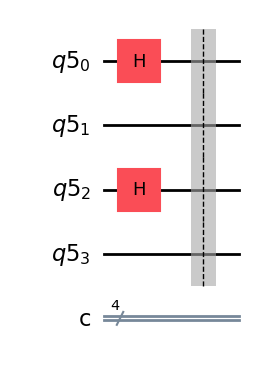

In [180]:
cr = ClassicalRegister(4,"c")
qr = QuantumRegister(4)
qc = QuantumCircuit(qr,cr)
qc.h(0) 
qc.h(2)  
qc.barrier()

qc.draw("mpl")

### 4.1.2 2단계 - 첫 번째 CNOT layer 추가

$(q_2,q_1)$에 Bell pair을 만듭니다. 두 qubit이 얽히면서 connectivity가 형성됩니다.

$$|\psi_2\rangle = \tfrac12\big(|0000\rangle + |0001\rangle + |0110\rangle + |0111\rangle\big).$$


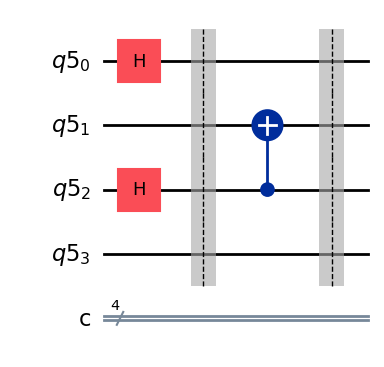

In [181]:
qc.cx(2, 1) 
qc.barrier()
qc.draw("mpl")

### 4.1.3 3단계 - 두 번째 CNOT layer 추가

$CX(0,1)$은 $q_0$를 연결 qubit에 반영하고, $CX(2,3)$은 $q_2$를 가장자리 qubit과 얽히게 합니다.

$$|\psi_3\rangle = \tfrac12\big(|0000\rangle + |0011\rangle + |1110\rangle + |1101\rangle\big).$$

동전 변수 $a_0=q_0$와 $a_2=q_2$로 나타내면, 종속적인 qubit은 이제

$$q_1 = a_0 \oplus a_2, \qquad q_3 = a_2$$

를 만족합니다.

연결 qubit $q_1$은 두 이웃의 **패리티**를 저장합니다. 이를 측정하면 $a_0$와 $a_2$가 같은지 알 수 있습니다.


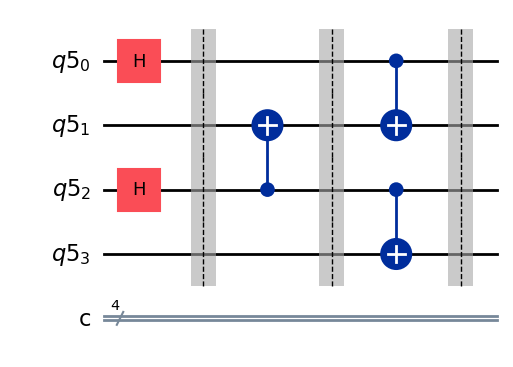

In [182]:
qc.cx(0, 1)
qc.cx(2, 3)   
qc.barrier()
qc.draw("mpl")

### 4.1.4 4단계 - 연결 qubit 측정 및 보정(feed-forward)

연결 qubit $q_1$을 측정하면 무작위 비트 $m_1 = a_0 \oplus a_2$를 얻습니다. 이는 두 동전 값이 같은지를 알려줍니다. 두 측정 결과는 서로 *다른* 상태를 남깁니다.

- $m_1 = 0:\quad \tfrac{1}{\sqrt2}\big(|0000\rangle + |1101\rangle\big)$
- $m_1 = 1:\quad \tfrac{1}{\sqrt2}\big(|0011\rangle + |1110\rangle\big)$

$q_1$을 $|0\rangle$으로 reset한 뒤, **$m_1 = 1$일 때만** 다음 qubit 쌍 $q_2, q_3$를 반전합니다. 보정 후에는 *두 측정 결과 모두* 동일한 상태를 만듭니다.

$$|\psi_4\rangle = \tfrac{1}{\sqrt2}\big(|0000\rangle + |1101\rangle\big).$$

고전적으로 제어된 $X$가 무작위 측정 결과의 영향을 제거합니다. 이것이 feed-forward의 핵심입니다. 측정 결과 자체는 무작위이지만, 고전적으로 제어된 $X$가 그 무작위성을 지워 $q_0, q_2, q_3$에 결정론적인 3-qubit GHZ state를 남깁니다. 이때 $q_1 = 0$입니다.


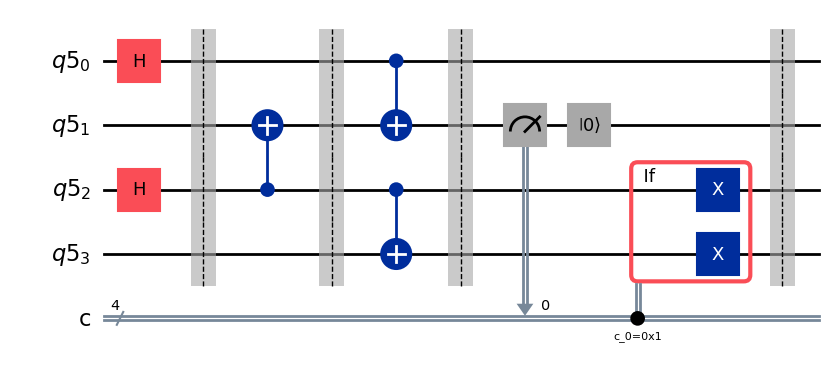

In [183]:
qc.measure(1, cr[0])             # 연결 qubit q1 측정
qc.reset(1)                      # |0> 상태로 reset
with qc.if_test((cr[0], 1)):     # 측정 결과가 1이면...
    qc.x(2)                      # ...다음 qubit 쌍(q2, q3)을 반전
    qc.x(3)
qc.barrier()
qc.draw("mpl")

### 4.1.5 5단계 - 가장자리 qubit 측정 및 reset

qubit 수가 짝수이면 가장자리 qubit $q_3$은 $q_2$의 남은 짝이며, 마지막 계층에서 다시 사용됩니다. 따라서 먼저 이를 측정하고 reset합니다. $q_3 = m_3$을 측정한 뒤 reset하면

- $m_3 = 0 \;\Rightarrow\; |0000\rangle$
- $m_3 = 1 \;\Rightarrow\; |0101\rangle$

을 얻습니다.

$q_3$의 측정은 공유된 값을 확정하며, 그 결과 $q_0 = q_2 = m_3$가 됩니다.


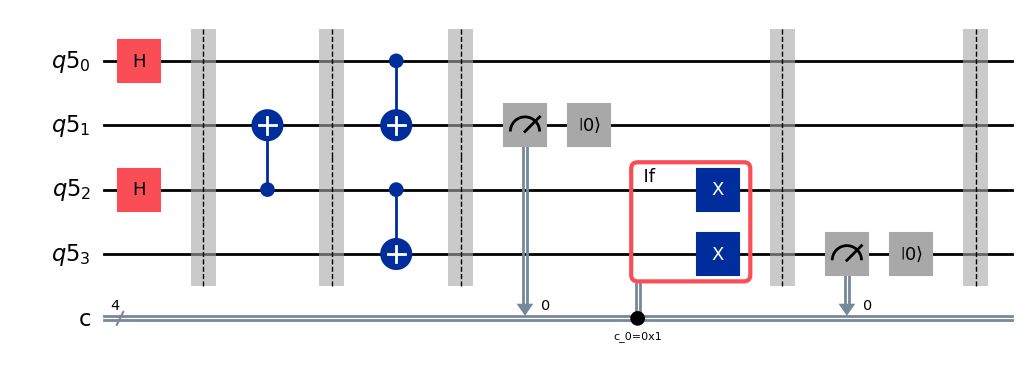

In [184]:
qc.measure(3, cr[0])   # 가장자리 qubit q3 측정(cr[0] 재사용)
qc.reset(3)            # |0> 상태로 reset
qc.barrier()
qc.draw("mpl")


### 4.1.6 6단계 - 마지막 CNOT layer 및 읽기

이제 $q_0$와 $q_2$는 동일하게 확정된 값 $m_3$을 가지며, $q_1$과 $q_3$은 $0$입니다. $CX(0,1)$은 $q_1$과 $q_0$를 얽히게 하고, $CX(2,3)$은 $q_3$과 $q_2$를 얽히게 하므로 네 qubit이 모두 같은 값을 갖게 됩니다.

- $m_3 = 0 \;\Rightarrow\; |0000\rangle$
- $m_3 = 1 \;\Rightarrow\; |1111\rangle$

따라서 매 실행에서 모든 비트가 0이거나 모든 비트가 1인 결과만 측정됩니다. 이것이 GHZ state의 특징입니다.


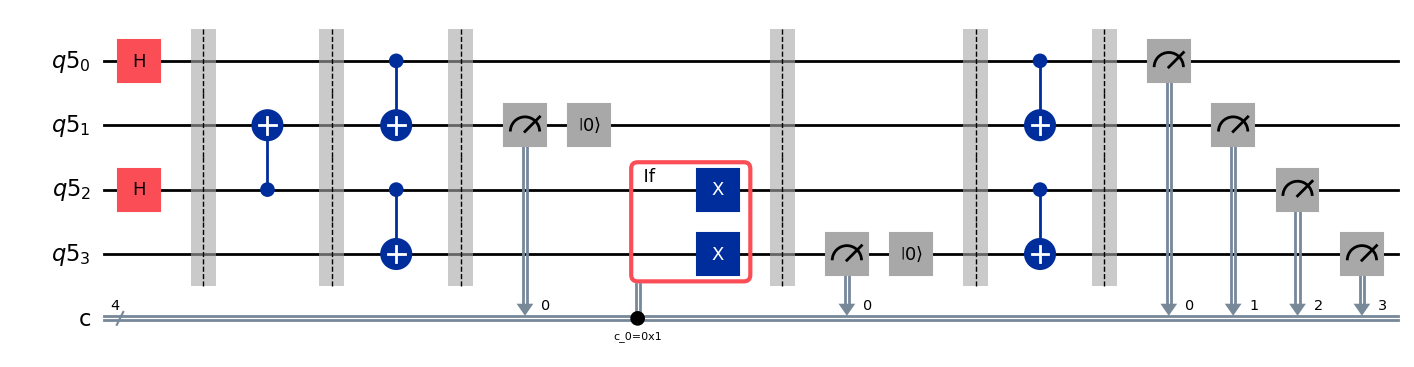

In [185]:
qc.cx(0, 1)
qc.cx(2, 3)
qc.barrier()
qc.measure(range(4), range(4))   # 모든 qubit 읽기
qc.draw("mpl")

### 4.1.7 실행

회로를 샘플링하면 $0000$과 $1111$이 대략 50:50의 비율로 나타나고 다른 결과는 거의 없어야 합니다.


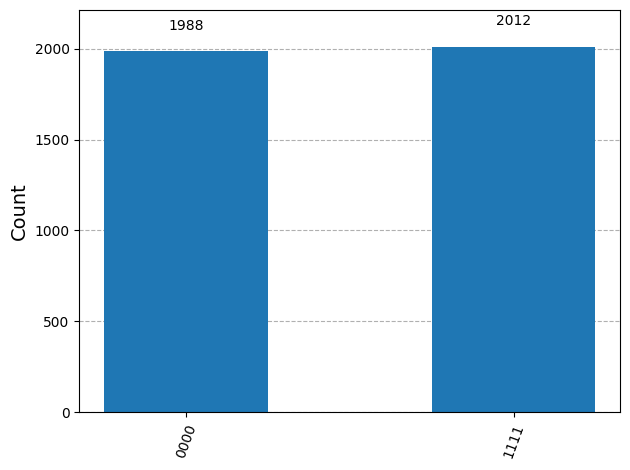

In [186]:
from qiskit_aer import AerSimulator

counts = AerSimulator().run(qc, shots=4000).result().get_counts()
plot_histogram(counts)

<div class="alert alert-block alert-success">
<b>연습문제 6.</b>
    <br>
  <b>create_dynamic_ghz_circuit</b>에서 dynamic GHZ 회로를 생성하는 함수를 작성하세요.<br>
</div>


In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.classical import expr


def dynamic_ghz_circuit(num_qubits: int) -> QuantumCircuit:
    """
    mid-circuit measurement와 classical feed-forward 연산을 사용해
    dynamic GHZ 회로를 구성합니다.

    인수:
        num_qubits: qubit 수(2 이상이어야 함).

    반환값:
        dynamic GHZ 프로토콜을 구현한 QuantumCircuit입니다.

    예외:
        ValueError: num_qubits가 2보다 작을 때 발생합니다.
    """
    if not isinstance(num_qubits, int) or num_qubits < 2:
        raise ValueError("num_qubits는 2 이상의 정수여야 합니다.")

    qr = QuantumRegister(num_qubits, name="q")
    cr = ClassicalRegister(num_qubits, name="c")
    qc = QuantumCircuit(qr, cr)

    _apply_initial_hadamards(qc, num_qubits)
    _apply_first_cnot_layer(qc, num_qubits)
    _apply_second_cnot_layer(qc, num_qubits)
    _apply_dynamic_section(qc, qr, cr, num_qubits)
    _apply_final_cnot_layer(qc, num_qubits)

    qc.measure(qr, cr)

    return qc


# --- 도우미 함수 ---

def _apply_initial_hadamards(qc: QuantumCircuit, num_qubits: int) -> None:
    """
    인덱스가 짝수인 모든 qubit에 Hadamard gate를 적용합니다.
    """
    # 여기에 코드를 작성하세요


def _apply_first_cnot_layer(qc: QuantumCircuit, num_qubits: int) -> None:
    """
    CNOT gate를 적용합니다: 제어=짝수 인덱스, 타깃=바로 앞 홀수 인덱스 qubit.
    예: CX(2,1), CX(4,3), CX(6,5), ...
    """
    # 여기에 코드를 작성하세요


def _apply_second_cnot_layer(qc: QuantumCircuit, num_qubits: int) -> None:
    """
    CNOT gate를 적용합니다: 제어=짝수 인덱스, 타깃=바로 뒤 홀수 인덱스 qubit.
    예: CX(0,1), CX(2,3), CX(4,5), ...
    """
    # 여기에 코드를 작성하세요


def _apply_dynamic_section(
    qc: QuantumCircuit,
    qr: QuantumRegister,
    cr: ClassicalRegister,
    num_qubits: int,
) -> None:
    """
    classical feed-forward를 사용하는 mid-circuit measurement을 수행합니다.
    qubit 수의 홀짝에 따라 주 반복문과 경계 qubit을 모두 처리합니다.


    """
    # 주요 동적 반복문
    # 여기에 코드를 작성하세요

    # 경계 처리
    # 여기에 코드를 작성하세요


def _apply_final_cnot_layer(qc: QuantumCircuit, num_qubits: int) -> None:
    """
    마지막 CNOT gate를 적용합니다: 제어=짝수 인덱스, 타깃=바로 뒤 홀수 인덱스 qubit.
    _apply_second_cnot_layer와 같은 패턴입니다.


    """
    # 여기에 코드를 작성하세요


def _measure_reset_and_correct(
    qc: QuantumCircuit,
    qr: QuantumRegister,
    cr: ClassicalRegister,
    meas_qubit: int,
    x_targets: list[int],
) -> None:
    """
    qubit을 cr[0]에 측정하고 reset한 뒤, 측정 결과에 따라
    target qubit에 조건부 X gate를 적용합니다.
    """
    # 여기에 코드를 작성하세요


def _measure_and_reset_only(
    qc: QuantumCircuit,
    qr: QuantumRegister,
    cr: ClassicalRegister,
    qubit: int,
) -> None:
    """
    qubit을 cr[0]에 측정하고 feed-forward 보정 없이 reset합니다.
    """
    # 여기에 코드를 작성하세요


num_qubits = 12
qc_dynamic_ghz = dynamic_ghz_circuit(num_qubits)
qc_dynamic_ghz.draw("mpl", fold=-1)

결과를 확인하려면 `00...00`과 `11...11` 상태의 확률이 대략 같아야 합니다.


In [ ]:
plot_histogram(transpile_and_run_counts(ideal_backend , qc_dynamic_ghz))

In [ ]:
grade_lab2_ex6(build_circuit=dynamic_ghz_circuit)

이제 서로 다른 backend에서 이 구현을 비교하고, 특정 `initial_layout`에 어느 backend가 더 적합한지 평가합니다.


In [ ]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

initial_layout_dynamic = [3,4,5,6,8,9,11,12,14,15,17,20]

pm_heron =  generate_preset_pass_manager(backend = backend_heron,initial_layout =initial_layout_dynamic,optimization_level=3)
pm_nightawk =  generate_preset_pass_manager(backend = backend_nighthawk,initial_layout =initial_layout_dynamic,optimization_level=3)


qc_dynamic_ghz_heron = pm_heron.run(qc_dynamic_ghz)
qc_dynamic_ghz_nighthawk = pm_nightawk.run(qc_dynamic_ghz)


<div class="alert alert-block alert-success">
<b>연습문제 7.</b>
    <br>
  quantum circuit 평가에 필요한 핵심 특성을 얻도록 <b>quantum_circuit_params</b> 함수를 구현하세요.<br>
</div>


In [ ]:
def quantum_circuit_params(circuit: QuantumCircuit) -> dict:
    """
    QuantumCircuit에서 핵심 매개변수를 추출합니다.

    인수:
        circuit: 분석할 QuantumCircuit입니다.

    반환값:
        다음 키를 갖는 딕셔너리입니다.
            - "Number of qubits": 회로의 전체 qubit 수
            - "Depth": circuit depth(gate의 최장 경로)
            - "2-qubit depth": 2-qubit gate만 고려한 깊이
            - "Gates": gate 이름과 개수의 딕셔너리
            - "Multi-qubit gates": multi-qubit gate 연산의 전체 수
            - "Number of ancillas": ancilla qubit 수
    """
    depth = # 여기에 코드를 작성하세요
    depth_2q = # 여기에 코드를 작성하세요
    num_multi_qubit_ops = # 여기에 코드를 작성하세요
    ops = # 여기에 코드를 작성하세요
    num_qubits = # 여기에 코드를 작성하세요
    num_ancillas = # 여기에 코드를 작성하세요

    return {
        "Number of qubits": num_qubits,
        "Depth": depth,
        "2-qubit depth": depth_2q,
        "Gates": ops,
        "Multi-qubit gates": num_multi_qubit_ops,
        "Number of ancillas": num_ancillas,
    }

quantum_circuit_params(qc_dynamic_ghz_nighthawk), quantum_circuit_params(qc_dynamic_ghz_heron)

In [ ]:
grade_lab2_ex7( quantum_circuit_params=quantum_circuit_params,build_circuit=dynamic_ghz_circuit) 

앞에서 계산한 결과는 아래와 같이 시각화할 수 있습니다.


In [ ]:

def plot_circuit_comparison(circuits_dict, figsize=(14, 6)):
    QISKIT_COLORS = [
        '#6929C4',  # 보라색(Qiskit 기본 색상)
        '#1192E8',  # 파란색
    ]
    # 모든 회로의 매개변수 추출
    all_params = {}
    for name, circuit in circuits_dict.items():
        all_params[name] = quantum_circuit_params(circuit)
    
    # 그래프용 데이터 준비
    circuit_names = list(all_params.keys())
    metrics = ["Number of qubits", "Depth", "2-qubit depth"]
    metric_labels = {
        "Number of qubits": "qubit 수",
        "Depth": "circuit depth",
        "2-qubit depth": "2-qubit 깊이",
    }
    
    # 서브플롯 생성(1행 4열)
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    fig.suptitle('quantum circuit 매개변수 비교', fontsize=16, fontweight='bold')
    
    # Qiskit 색상 사용
    colors = [QISKIT_COLORS[i % len(QISKIT_COLORS)] for i in range(len(circuit_names))]
    
    # 처음 세 서브플롯에 각 지표 표시
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        values = [all_params[name][metric] for name in circuit_names]
        
        bars = ax.bar(range(len(circuit_names)), values, color=colors, 
                      edgecolor='#000000', linewidth=1.5, alpha=0.85)
        
        ax.set_xlabel('회로', fontsize=11, fontweight='bold')
        ax.set_ylabel(metric_labels[metric], fontsize=11, fontweight='bold')
        ax.set_title(metric_labels[metric], fontsize=12, fontweight='bold', pad=10)
        ax.set_xticks(range(len(circuit_names)))
        ax.set_xticklabels(circuit_names, rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3, linestyle='--', color='#CCCCCC')
        ax.set_facecolor('#F7F7F7')
        
        # 막대에 값 레이블 추가
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{value}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # gate 연산 비교(마지막 서브플롯)
    ax = axes[3]
    gate_types = set()
    for params in all_params.values():
        if isinstance(params["Gates"], dict):
            gate_types.update(params["Gates"].keys())
    
    if gate_types:
        gate_types = sorted(gate_types)
        x = np.arange(len(gate_types))
        width = 0.8 / len(circuit_names)
        
        for i, name in enumerate(circuit_names):
            gates = all_params[name]["Gates"]
            counts = [gates.get(gate, 0) for gate in gate_types]
            offset = (i - len(circuit_names)/2) * width + width/2
            ax.bar(x + offset, counts, width, label=name, 
                   color=colors[i], edgecolor='#000000', linewidth=1, alpha=0.85)
        
        ax.set_xlabel('gate 종류', fontsize=11, fontweight='bold')
        ax.set_ylabel('개수', fontsize=11, fontweight='bold')
        ax.set_title('gate 연산 구성', fontsize=12, fontweight='bold', pad=10)
        ax.set_xticks(x)
        ax.set_xticklabels(gate_types, rotation=45, ha='right')
        ax.legend(fontsize=9, framealpha=0.9)
        ax.grid(axis='y', alpha=0.3, linestyle='--', color='#CCCCCC')
        ax.set_facecolor('#F7F7F7')
    else:
        ax.text(0.5, 0.5, '사용 가능한 gate 데이터가 없습니다', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.axis('off')
    
    plt.tight_layout()
    return fig

circuits = {
        "heron": qc_dynamic_ghz_heron,
        "nightawk": qc_dynamic_ghz_nighthawk
    }

fig = plot_circuit_comparison(circuits)
plt.show()


축하합니다! 실습 2를 마쳤습니다. 이번 실습에서는 noise의 구성을 이해하고, 하드웨어 수준의 물리적 특성을 고려해 영향을 줄이며, dynamic circuit을 사용해 quantum circuit을 최적화하는 데 필요한 핵심 도구를 배웠습니다. 여기서 다룬 도구는 양자 하드웨어를 사용하고, 서로 다른 architecture를 분석하며, 실제 하드웨어에서 알고리즘을 구현할 때의 장점을 파악하는 데 유용합니다.


<a id="bonus"></a>
# 보너스

앞 절에서는 simulator와 fake backend에서 dynamic GHZ 회로를 실행했습니다.
이 보너스 절에서는 `qiskit-ibm-runtime`을 사용해 회로를 **실제 IBM Quantum 하드웨어**에 제출합니다.

실제 하드웨어에서 실행하면 지금까지 배운 모든 요소가 영향을 줍니다.

- gate error, readout noise, decoherence, 하드웨어 connectivity 제약.
- dynamic circuit 방식은 mid-circuit measurement와 feed-forward 고전 제어가 IBM Quantum 장치에서 비교적 최근에 지원되기 시작했다는 점에서 특히 흥미롭습니다. 따라서 현대 양자 하드웨어의 기능을 실제로 시험하는 사례가 됩니다.


#### 인증 및 backend 선택

실제 하드웨어에서 실행하려면 [IBM Quantum 계정](https://quantum.cloud.ibm.com/)이 필요합니다.
`QiskitRuntimeService.save_account(...)`를 사용해 API 토큰을 한 번 저장하면 이후 세션에서 자동으로 재사용됩니다.

**dynamic circuit 지원:** 모든 IBM Quantum backend가 mid-circuit measurement와 classical feed-forward를 지원하는 것은 아닙니다. `dynamic_reprate_enabled` 플래그를 확인하거나 backend의 `operations` 목록에 `if_else`가 있는지 확인하세요. Eagle/Heron 장치는 일반적으로 이 기능을 지원합니다. 선택한 backend가 지원하지 않으면 transpiler에서 오류가 발생합니다.


In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

# -------------------------------------------------------------------
# 1a. 인증 정보를 한 번 저장합니다(한 번만 실행한 뒤 다시 주석 처리):
# QiskitRuntimeService.save_account(
#     channel="ibm_cloud",
#     token="<YOUR_IBM_QUANTUM_API_TOKEN>",
#     overwrite=True,
# )
# -------------------------------------------------------------------

# 1b. 저장된 인증 정보를 불러와 IBM Cloud 채널에 연결합니다.
service = QiskitRuntimeService(channel="ibm_cloud")

# 1c. dynamic circuit을 지원하고 12-qubit GHZ 실험에 충분한 qubit을 갖는
#     backend 중 대기열이 가장 짧은 backend를 선택합니다.
backend_hw = service.least_busy(
    operational=True,
    min_num_qubits=12,
    dynamic_circuits=True,       # dynamic circuit 지원 필요
)

print(f"선택한 backend : {backend_hw.name}")
print(f"qubit 수 : {backend_hw.num_qubits}")
print(f"상태 : {backend_hw.status().status_msg}")
print(f"대기열 길이 : 대기 중인 작업 {backend_hw.status().pending_jobs}개")

#### 하드웨어 속성 확인

작업을 제출하기 전에 1장에서 살펴본 gate error, readout error, coherence time 등의 backend 속성을 확인하는 것이 좋습니다.
이 정보는 좋은 initial layout을 선택하고 현실적인 결과를 예상하는 데 도움이 됩니다.


In [ ]:
plot_gate_map(backend_hw)

#### initial layout 선택

4장에서 만든 것과 동일한 12-qubit dynamic GHZ 회로를 사용합니다.
`initial_layout_dynamic` 목록은 12개의 logical qubit을 선택한 backend에서 connectivity이 좋고 오류율이 낮은 physical qubit에 매핑합니다.

backend의 topology가 다르거나 위 오류 표에서 더 좋은 qubit 후보를 찾았다면 아래 목록을 조정하세요.


In [ ]:
# 4장의 12-qubit dynamic GHZ 회로를 재사용합니다.
num_qubits_bonus = 12
qc_bonus = dynamic_ghz_circuit(num_qubits_bonus)

# 선택한 backend에서 특성이 좋은 physical qubit을 선택합니다.
# 이 layout은 Heron 및 유사한 heavy-hex 장치에서 잘 동작합니다.
# 다른 backend에서는 위 gate 맵과 오류 표를 참고해 수정하세요.
initial_layout_hw = [3, 4, 5, 6, 8, 9, 11, 12, 14, 15, 17, 20]

# 최적화 수준 1의 프reset 패스 매니저를 구성하고 실행합니다.
# transpile을 결정론적으로 유지하고 패스 매니저가 mid-circuit measurement 순서를
# 바꾸지 않도록 수준 3 대신 수준 1을 사용합니다.
pm_hw = generate_preset_pass_manager(
    backend=backend_hw,
    initial_layout=initial_layout_hw,
    optimization_level=1,
)

qc_bonus_transpiled = pm_hw.run(qc_bonus)

print("transpiled circuit 매개변수:")
parameter_labels = {
    "Number of qubits": "qubit 수",
    "Depth": "circuit depth",
    "2-qubit depth": "2-qubit 깊이",
    "Multi-qubit gates": "multi-qubit gate 수",
    "Number of ancillas": "ancilla qubit 수",
}
params = quantum_circuit_params(qc_bonus_transpiled)
for k, v in params.items():
    if k != 'Gates':
        print(f"  {parameter_labels.get(k, k)}: {v}")
print(f"  gate 구성: {dict(params['Gates'])}")

#### 하드웨어에 제출

Qiskit Runtime 서비스를 통해 IBM Quantum 하드웨어에서 회로를 실행할 때는 `SamplerV2` 사용이 권장됩니다. 세션 관리, 작업 대기열 처리, 결과 패키징을 대신 수행합니다.


In [ ]:
shots_hw = 4096

sampler_hw = Sampler(mode=backend_hw)
job_hw = sampler_hw.run([qc_bonus_transpiled], shots=shots_hw)

print(f"작업 ID : {job_hw.job_id()}")
print(f"상태 : {job_hw.status()}")
print("작업이 완료되기를 기다리는 중입니다(몇 분 정도 걸릴 수 있습니다)...")

In [ ]:
# 결과를 사용할 수 있을 때까지 대기합니다.
# backend가 혼잡하면 수초에서 수십 분까지 걸릴 수 있습니다.
result_hw = job_hw.result()

# 첫 번째이자 유일한 pub 결과에서 카운트를 추출합니다.
cr_keys = list(result_hw[0].data.keys())
counts_hw = result_hw[0].data[cr_keys[0]].get_counts()

print(f"전체 number of shots : {sum(counts_hw.values())}")
print("상위 10개 결과:")
for bitstring, count in sorted(counts_hw.items(), key=lambda x: -x[1])[:10]:
    print(f"  {bitstring}: {count}")

#### 실제 하드웨어와 이상적 simulator 비교

이제 *동일하게 transpiled circuit*를 이상적 `AerSimulator`에서 실행하고, 두 분포를 나란히 표시합니다. 이를 통해 실제 하드웨어가 이상적인 GHZ state에서 얼마나 벗어나는지 직접 시각적으로 확인할 수 있습니다.


In [ ]:
def top_n(counts, n=10):
    """카운트가 큰 상위 n개 비트열만 포함하는 새 딕셔너리를 반환합니다."""
    return dict(sorted(counts.items(), key=lambda x: x[1], reverse=True)[:n])

# 비교를 위해 transpiled circuit을 이상적 AerSimulator에서 실행합니다.
ideal_backend_bonus = AerSimulator()
counts_ideal_bonus = run_counts(ideal_backend_bonus, qc_bonus_transpiled, shots=shots_hw)

# 각 분포에서 상위 10개만 유지합니다.
top_ideal = top_n(counts_ideal_bonus, 10)
top_hw    = top_n(counts_hw, 10)

# 나란히 표시한 히스토그램
plot_histogram(
    [top_ideal, top_hw],
    legend=["이상적 simulator", f"하드웨어 ({backend_hw.name})"],
    figsize=(14, 5),
    title="dynamic GHZ (12 qubit): 이상적 simulator와 실제 하드웨어 비교 (상위 10개)",
)

<a id="wrap-up"></a>
# 마무리

이 보너스 절에서는 다음 작업을 수행했습니다.

- IBM Quantum 클라우드에 인증하고 dynamic circuit을 지원하는 real backend를 선택했습니다.
- qubit 선택에 활용하기 위해 하드웨어 속성인 gate error, readout error, coherence time을 확인했습니다.
- 해당 backend에 맞게 12-qubit dynamic GHZ 회로를 transpile했습니다.

fake backend의 예측과 실제 하드웨어 결과 사이의 차이는 보정된 noise model이 완전히 포착하지 못하는 누화, 누설, 시간에 따른 드리프트, classical feed-forward가 도입하는 오버헤드 등의 noise 원인을 반영합니다.
이 차이를 줄이는 것은 quantum error mitigation 연구의 핵심 목표 중 하나입니다.
